# Branch-and-Sandwich — Mutable Line Limits
## Applied to 6-bus, IEEE 14-bus, IEEE 30-bus, IEEE 39-bus, IEEE 57-bus, IEEE 118-bus, IEEE 300-bus

**Algorithm:** Branch-and-Sandwich WCE (Weakly Counterfactual Explanation)  
**Mutable parameter:** Line flow limits (`b` vector / `fmax`)  
**Foil:** Emissions reduction by α = 20 %  
**Special case (6-bus):** also run with a commitment-flip foil for comparison

**Structure**
- Section 0 — Imports and helpers
- Section 1 — Dataset loading
- Section 2 — Factual UC solve and emissions baseline per grid
- Section 3 — Branch-and-Sandwich for each grid with plots
- Section 4 — Cross-grid comparison

## 0 · Imports and helpers

In [1]:
import os, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from dataclasses import replace
from typing import Optional, Callable, Dict, Tuple

import gurobipy as gp
from gurobipy import GRB

#os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"

import uc_pipeline, uc_data_loader, uc_branch_sandwich_4b, uc_master_relax_4b
importlib.reload(uc_pipeline)
importlib.reload(uc_data_loader)
importlib.reload(uc_branch_sandwich_4b)
importlib.reload(uc_master_relax_4b)

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
    make_emissions_foil_4b,
)
from uc_data_loader import quick_setup
from uc_branch_sandwich_4b import UCBranchAndSandwichWCE_4b

# ── Data folder ───────────────────────────────────────────────────────────
#DATA_DIR = r"C:\Users\tomas\Documents\GitHub\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"
DATA_DIR = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data"

ALPHA     = 0.10   # emissions reduction target
UTIL_THR  = 0.75  # congestion threshold: lines with utilisation >= this are mutable
maxnodes  = 1500   # maximum number of nodes in branch-and-sandwich tree
warnings.filterwarnings("ignore")
print("Imports OK")
print(f"Data directory: {DATA_DIR}")
print(f"Emissions reduction alpha = {ALPHA:.0%}  |  Congestion threshold = {UTIL_THR:.0%}")

Imports OK
Data directory: C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\Data
Emissions reduction alpha = 10%  |  Congestion threshold = 75%


### Oracle, line-limit helpers and plotting utilities

In [2]:
# ── replace_line_limits ──────────────────────────────────────────────────
def replace_line_limits(data: NetworkUCData, b_line: np.ndarray) -> NetworkUCData:
    b_line = np.asarray(b_line, dtype=float).reshape(-1)
    assert len(b_line) == len(data.lines)
    new_lines = [replace(L, fmax=float(b_line[ell])) for ell, L in enumerate(data.lines)]
    return replace(data, lines=new_lines)


# ── make_line_weights ─────────────────────────────────────────────────────
def make_line_weights(DATA, b0, util=None, alpha=1.0, beta=1.0, gamma=0.5, eps_u=0.05):
    """
    Weights based on reactance proxy, original limit, and inverse utilisation.
    Normalised to mean 1 and clipped to [0.1, 10].
    """
    b_susc  = np.array([float(L.b) for L in DATA.lines], dtype=float)
    x_proxy = 1.0 / np.maximum(np.abs(b_susc), 1e-9)
    x_med   = np.median(x_proxy)
    b0_med  = np.median(b0)
    w = (x_proxy / max(x_med, 1e-9))**alpha * (b0 / max(b0_med, 1e-9))**beta
    if util is not None:
        w *= (1.0 / (eps_u + util))**gamma
    w = w / np.mean(w)
    w = np.clip(w, 0.1, 10.0)
    return w


# ── congestion-threshold free lines ─────────────────────────────────────
def get_congested_free_lines(sol0, b0, thr=0.75):
    """
    Return indices of all lines whose peak utilisation >= thr in the factual sol.
    Falls back to the single most-utilised line if none exceed the threshold.
    """
    f_abs_max = np.max(np.abs(sol0["f"]), axis=1)     # (nL,)
    util      = f_abs_max / np.maximum(b0, 1e-9)
    idx_cong  = [ell for ell in range(len(b0)) if util[ell] >= thr]
    if len(idx_cong) == 0:
        idx_cong = [int(np.argmax(util))]  # safe fallback
    return idx_cong, util


# ── build b-bounds ────────────────────────────────────────────────────────
def build_b_bounds(b0, b_free_idx, scale_up=1.2):
    """Lower bound = b0 (no tightening), upper bound = scale_up * b0."""
    bL = b0.copy()
    bU = b0.copy()
    for ell in b_free_idx:
        bU[ell] = scale_up * b0[ell]
    return bL, bU


# ── UCWeakWCEOracle ───────────────────────────────────────────────────────
class UCWeakWCEOracle:
    def __init__(self, data, cvec, idx, window_size, per_bus_neutrality,
                 u_init, p_init, on_t, off_t,
                 foil_extra_constr_fn=None,
                 output_flag=0, time_limit=None, cache_decimals=3):
        self.data               = data
        self.cvec               = np.asarray(cvec, float)
        self.idx                = idx
        self.window_size        = int(window_size)
        self.per_bus_neutrality = bool(per_bus_neutrality)
        self.u_init = u_init; self.p_init = p_init
        self.on_t   = on_t;   self.off_t  = off_t
        self.foil_extra_constr_fn = foil_extra_constr_fn
        self.output_flag  = int(output_flag)
        self.time_limit   = time_limit
        self.cache_decimals = int(cache_decimals)
        self.cache_plain  = {}
        self.cache_foil   = {}

    def _key(self, b_line):
        return tuple(np.round(np.asarray(b_line, float), self.cache_decimals))

    def _solve(self, b_line, extra_fn, cache):
        key = self._key(b_line)
        if key in cache:
            return cache[key]
        data_b = replace_line_limits(self.data, b_line)
        m, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size,
            per_bus_neutrality=self.per_bus_neutrality,
            u_init=self.u_init, p_init=self.p_init,
            on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=extra_fn,
            output_flag=self.output_flag,
            time_limit=self.time_limit,
            fmax_override=None,
        )
        out = (None, None, None) if sol is None else (float(sol["obj"]), np.array(z, float), sol)
        cache[key] = out
        return out

    def solve_plain(self, b_line):
        return self._solve(b_line, None, self.cache_plain)

    def solve_foil(self, b_line):
        return self._solve(b_line, self.foil_extra_constr_fn, self.cache_foil)


# ── Foil helpers (commitment-flip, used only for 6-bus bonus experiment) ─
def _as_list(x):
    if x is None: return []
    return list(x) if isinstance(x, (list, tuple, set)) else [x]

def _get_var(var, names):
    for n in names:
        if isinstance(var, dict) and n in var: return var[n]
        if hasattr(var, n): return getattr(var, n)
    raise KeyError(f"Could not find any of {names}")

def foil_force_on(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u", "U"])
        for t in times:
            m.addConstr(u[g, t] == 1, name=f"foil_on_g{g}_t{t}")
    return _f

def foil_force_off(g, times):
    times = _as_list(times)
    def _f(m, var, *a, **k):
        u = _get_var(var, ["u", "U"])
        for t in times:
            m.addConstr(u[g, t] == 0, name=f"foil_off_g{g}_t{t}")
    return _f

def scan_foil_candidates(data, idx, cvec, solF, zF,
                         window_size, per_bus_neutrality,
                         u_init, p_init, on_t, off_t,
                         min_gap=100, max_gap=1e7, block_len_range=(2, 4)):
    nG = len(data.gens)
    T  = int(data.T)
    factual_obj = float(np.dot(cvec, zF))
    candidates  = []
    print(f"Scanning foil candidates  (factual obj={factual_obj:.0f})")
    print(f"  g  times             gap    type  verdict")
    print("  " + "-"*55)
    def get_blocks(hrs):
        blocks = []
        if hrs:
            s = p = hrs[0]
            for t in hrs[1:]:
                if t != p+1: blocks.append((s, p)); s = t
                p = t
            blocks.append((s, p))
        return blocks
    for g in range(nG):
        gen = data.gens[g]
        if gen.UT > 1 or gen.DT > 1: continue
        uF_g    = solF["u"][g]
        on_hrs  = [t for t in range(T) if int(round(uF_g[t])) == 1]
        off_hrs = [t for t in range(T) if int(round(uF_g[t])) == 0]
        for (t0, t1), ftype in ([(b, "ON")  for b in get_blocks(off_hrs)] +
                                 [(b, "OFF") for b in get_blocks(on_hrs)]):
            for L in range(block_len_range[0], block_len_range[1]+1):
                if t0+L-1 > t1: continue
                times = list(range(t0, t0+L))
                foil  = foil_force_on(g, times) if ftype == "ON" else foil_force_off(g, times)
                _, solT, zT = solve_uc_with_cost_4b(
                    data=data, idx=idx, cvec=cvec,
                    window_size=window_size, per_bus_neutrality=per_bus_neutrality,
                    u_init=u_init, p_init=p_init,
                    on_time_init=on_t, off_time_init=off_t,
                    extra_constr_fn=foil, output_flag=0,
                )
                if solT is None: continue
                gap     = float(np.dot(cvec, zT)) - factual_obj
                ok      = min_gap < gap < max_gap
                verdict = "good" if ok else ("trivial" if gap <= min_gap else "too large")
                print(f"  g={g}  t={str(times):>15}  {gap:>8.0f}  {ftype:>4}  {verdict}")
                if ok: candidates.append((gap, g, times, ftype))
    candidates.sort()
    if candidates:
        print(f"\n  Best: G{candidates[0][1]} {candidates[0][3]} "
              f"t={candidates[0][2]} gap={candidates[0][0]:.0f}")
    else:
        print("\n  No good candidates found.")
    return candidates


TECH_COLORS = ["#73726c","#378ADD","#BA7517","#7F77DD","#1D9E75",
               "#D85A30","#639922","#5DCAA5","#EF9F27","#E24B4A"]

print("Helpers defined.")

Helpers defined.


### Plot function — `plot_bs_results`

In [11]:
def plot_bs_results(DATA, b0, b_hat, sol0, sol_plain_hat, sol_foil_hat,
                    res_bs, label="", foil_label="emissions −20%"):
    """
    Unified B&S results figure.  Four panels per grid:
      (1) Factual dispatch         (2) Counterfactual dispatch
      (3) Curtailment comparison   (4) Line-limit changes (per-unit b_hat / b0)
    Plus a summary print block.
    """
    if res_bs is None or not res_bs.get("success"):
        print(f"[{label}] No successful result — nothing to plot.")
        return

    nG = len(DATA.gens)
    nR = len(DATA.rens)
    T  = int(DATA.T)
    nL = len(DATA.lines)
    hrs = np.arange(T)

    # ── Figure: 3×2 grid ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(
        f"Branch-and-Sandwich — {label}   [foil: {foil_label}]",
        fontsize=13, fontweight="bold",
    )
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.28)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, 0])
    ax6 = fig.add_subplot(gs[2, 1])

    # ── Dispatch panels ───────────────────────────────────────────────────
    def _dispatch_panel(ax, sol, title):
        if sol is None:
            ax.set_title(f"{title} (N/A)"); return
        # Normalise p to a (nG, T) numpy array regardless of how the solver returns it
        p_raw = sol["p"]
        if isinstance(p_raw, dict):
            p_mat = np.array([[float(p_raw[g, t]) for t in range(T)] for g in range(nG)])
        else:
            p_mat = np.asarray(p_raw, dtype=float)
            if p_mat.shape == (T, nG):
                p_mat = p_mat.T
        sol = dict(sol, p=p_mat)
        bottom = np.zeros(T)
        for g in range(nG):
            col = TECH_COLORS[g % len(TECH_COLORS)]
            ax.fill_between(hrs, bottom, bottom + sol["p"][g],
                            color=col, alpha=0.75, label=f"G{g}", step="mid")
            bottom += sol["p"][g]
        if nR > 0 and "curt" in sol:
            avail = np.vstack([r.avail for r in DATA.rens])
            ren_inj = (avail - sol["curt"]).sum(axis=0)
            ax.fill_between(hrs, bottom, bottom + ren_inj,
                            color="#1D9E75", alpha=0.5, label="Renewable", step="mid")
            bottom += ren_inj
        ax.plot(hrs, bottom, color="orange", lw=1.8, label="Total production", zorder=5)
        ax.plot(hrs, DATA.demand.sum(axis=0), "k--", lw=1.5, label="Demand")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Hour"); ax.set_ylabel("MW")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=4, loc="upper left")

    _dispatch_panel(ax1, sol0,         "Factual dispatch  (b = b₀)")
    _dispatch_panel(ax2, sol_foil_hat, "Counterfactual dispatch  (b = b̂, foil active)")

    # ── Curtailment comparison ────────────────────────────────────────────
    curtF   = sol0["curt"].sum(axis=0)          if nR>0 and "curt" in sol0         else np.zeros(T)
    curtCF  = sol_foil_hat["curt"].sum(axis=0)  if sol_foil_hat is not None and nR>0 and "curt" in sol_foil_hat  else np.zeros(T)
    curtP   = sol_plain_hat["curt"].sum(axis=0) if sol_plain_hat is not None and nR>0 and "curt" in sol_plain_hat else np.zeros(T)

    ax3.bar(hrs - 0.27, curtF,  0.26, color="#D85A30", alpha=0.85, label=f"Factual  ({curtF.sum():.1f} MWh)")
    ax3.bar(hrs,        curtP,  0.26, color="#BA7517", alpha=0.85, label=f"Plain@b̂  ({curtP.sum():.1f} MWh)")
    ax3.bar(hrs + 0.27, curtCF, 0.26, color="#378ADD", alpha=0.85, label=f"Foil@b̂   ({curtCF.sum():.1f} MWh)")
    ax3.set_title("Curtailment per hour (MWh)", fontsize=10)
    ax3.set_xlabel("Hour"); ax3.set_ylabel("MWh")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis="y")

# ── Emissions per hour ────────────────────────────────────────────────
    e_g = np.array([float(g.emission_rate) for g in DATA.gens], dtype=float)

    def _emissions_per_hour(sol):
        if sol is None:
            return np.zeros(T)
        p_raw = sol["p"]
        if isinstance(p_raw, dict):
            p_mat = np.array([[float(p_raw[g, t]) for t in range(T)] for g in range(nG)])
        else:
            p_mat = np.asarray(p_raw, dtype=float)
            if p_mat.shape == (T, nG):
                p_mat = p_mat.T
        return e_g @ p_mat   # (nG,) @ (nG, T) -> (T,)

    emisF  = _emissions_per_hour(sol0)
    emisP  = _emissions_per_hour(sol_plain_hat)
    emisCF = _emissions_per_hour(sol_foil_hat)

    ax4.bar(hrs - 0.27, emisF,  0.26, color="#D85A30", alpha=0.85,
            label=f"Factual  ({emisF.sum():.1f} tCO₂)")
    ax4.bar(hrs,        emisP,  0.26, color="#BA7517", alpha=0.85,
            label=f"Plain@b̂  ({emisP.sum():.1f} tCO₂)")
    ax4.bar(hrs + 0.27, emisCF, 0.26, color="#378ADD", alpha=0.85,
            label=f"Foil@b̂   ({emisCF.sum():.1f} tCO₂)")
    ax4.axhline(emisF.mean(), color="#D85A30", lw=1.0, ls="--", alpha=0.6)
    ax4.set_title("Emissions per hour (tCO₂)", fontsize=10)
    ax4.set_xlabel("Hour"); ax4.set_ylabel("tCO₂/h")
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis="y")

    # ── Line-limit changes (per-unit) ─────────────────────────────────────
    # (move this block to ax5 instead of ax4)
    b_hat_pu = b_hat / np.maximum(b0, 1e-12)
    changed  = np.where(np.abs(b_hat_pu - 1.0) > 1e-4)[0]
    x_all    = np.arange(nL)

    ax5.bar(x_all, b_hat_pu, color="#cccccc", alpha=0.6, label="Unchanged")
    if len(changed):
        ax5.bar(changed, b_hat_pu[changed], color="#378ADD", alpha=0.9, label="Changed")
    ax5.axhline(1.0, color="k", lw=1.0, ls="--", label="Original (1.0 p.u.)")
    ax5.set_title("Line limits — counterfactual vs original  (p.u.)", fontsize=10)
    ax5.set_xlabel("Line index ℓ"); ax5.set_ylabel("b̂ / b₀  (p.u.)")
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3, axis="y")
    ax5.text(0.98, 0.97, f"{len(changed)} line(s) changed",
             transform=ax5.transAxes, ha="right", va="top", fontsize=8)

    # ── Summary text panel ────────────────────────────────────────────────
    F_best  = float(res_bs.get("F_opt", np.nan))
    LB      = res_bs.get("global_LB", res_bs.get("LB", np.nan))
    LB      = float(LB) if LB is not None else np.nan
    gap_pct = (100.0 * max(0.0, F_best - LB) / abs(F_best)
               if np.isfinite(F_best) and np.isfinite(LB) and abs(F_best) > 1e-12
               else np.nan)
    emis_red_pct = (100.0 * (emisF.sum() - emisCF.sum()) / max(emisF.sum(), 1e-9)
                    if emisCF.sum() > 0 else np.nan)

    summary_lines = [
        f"Nodes processed : {res_bs.get('nodes')}",
        f"F_opt (incumbent): {F_best:.6f}",
        f"Global LB        : {LB:.6f}",
        f"Gap              : {gap_pct:.3f}%",
        f"Certified        : {res_bs.get('certified')}",
        f"",
        f"Emissions factual : {emisF.sum():.2f} tCO₂",
        f"Emissions foil@b̂ : {emisCF.sum():.2f} tCO₂",
        f"Reduction         : {emis_red_pct:.2f}%",
        f"Target reduction  : {ALPHA:.0%}",
    ]
    ax6.axis("off")
    ax6.text(0.05, 0.95, "\n".join(summary_lines),
             transform=ax6.transAxes, va="top", ha="left",
             fontsize=10, fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))
    ax6.set_title("Summary", fontsize=10)    # ── Numeric summary ───────────────────────────────────────────────────
    F_best = float(res_bs.get("F_opt", np.nan))
    LB     = res_bs.get("global_LB", res_bs.get("LB", np.nan))
    LB     = float(LB) if LB is not None else np.nan
    gap_pct = (100.0 * max(0.0, F_best - LB) / abs(F_best)
               if np.isfinite(F_best) and np.isfinite(LB) and abs(F_best) > 1e-12
               else np.nan)

    print(f"\n{label} — B&S summary:")
    print(f"  Nodes processed : {res_bs.get('nodes')}")
    print(f"  F_opt (incumbent): {F_best:.6f}")
    print(f"  Global LB        : {LB:.6f}")
    print(f"  Gap              : {gap_pct:.3f}%")
    print(f"  Certified        : {res_bs.get('certified')}")

    if len(changed):
        delta_abs = b_hat - b0
        delta_pu  = delta_abs / np.maximum(b0, 1e-12)
        util_arr  = np.max(np.abs(sol0["f"]), axis=1) / np.maximum(b0, 1e-9)
        print(f"  {'ell':>4}  {'fr->to':>6}  {'b0(MW)':>9}  {'b_hat(MW)':>10}  {'Δ(MW)':>8}  "
              f"{'b_hat(pu)':>10}  {'Δ(pu)':>8}  {'util':>6}")
        rows = sorted(
            [(ell, int(DATA.lines[ell].fr), int(DATA.lines[ell].to),
              b0[ell], b_hat[ell], delta_abs[ell], b_hat_pu[ell], delta_pu[ell], util_arr[ell])
             for ell in changed],
            key=lambda r: -abs(r[7]),
        )
        for ell, fr, to, b0v, bhv, dv, bhpu, dpu, uti in rows:
            print(f"  {ell:>4}  {fr:>2}->{to:<3}  {b0v:>9.3f}  {bhv:>10.3f}  {dv:>8.3f}  "
                  f"{bhpu:>10.3f}  {dpu:>+8.3f}  {uti:>6.3f}")
    else:
        print("  (No line limits changed.)")

print("plot_bs_results defined.")

plot_bs_results defined.


---
## Section 1 · Dataset loading

Load all seven IEEE benchmark grids from JSON files in `DATA_DIR`.
`quick_setup` returns `DATA, idx, cvec, b0, u_init, p_init, on_t, off_t`.

### Smaller grids (6-bus, 14-bus, 30-bus)   

In [30]:
import os as _os
DATA_6, idx_6, cvec_6, b0_6, \
    u_init_6, p_init_6, on_t_6, off_t_6 = quick_setup(
    _os.path.join(DATA_DIR, "6bus_wood_wollenberg.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
)
print(f"6-bus (Wood & Wollenberg)  |  buses={DATA_6.nB}  lines={len(DATA_6.lines)}  "
      f"gens={len(DATA_6.gens)}  T={int(DATA_6.T)}h")

Loaded: 6bus_wood_wollenberg.json
  Buses: 6  |  Lines: 9  |  T: 24h
  Generators: 3  |  Renewables: 2
  System peak demand: 286.4 MW
  Total renewable capacity: 280.0 MW
  Carbon price: 50.0 $/tCO2
6-bus (Wood & Wollenberg)  |  buses=6  lines=9  gens=3  T=24h


In [31]:
import os as _os
DATA_14, idx_14, cvec_14, b0_14, \
    u_init_14, p_init_14, on_t_14, off_t_14 = quick_setup(
    _os.path.join(DATA_DIR, "ieee14_enhanced.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
)
print(f"IEEE 14-bus  |  buses={DATA_14.nB}  lines={len(DATA_14.lines)}  "
      f"gens={len(DATA_14.gens)}  T={int(DATA_14.T)}h")

Loaded: ieee14_enhanced.json
  Buses: 14  |  Lines: 20  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 648.4 MW
  Total renewable capacity: 570.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 14-bus  |  buses=14  lines=20  gens=6  T=24h


In [32]:
import os as _os
DATA_30, idx_30, cvec_30, b0_30, \
    u_init_30, p_init_30, on_t_30, off_t_30 = quick_setup(
    _os.path.join(DATA_DIR, "ieee30_uc.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
    demand_scaling=0.8,
)
print(f"IEEE 30-bus  |  buses={DATA_30.nB}  lines={len(DATA_30.lines)}  "
      f"gens={len(DATA_30.gens)}  T={int(DATA_30.T)}h")

Loaded: ieee30_uc.json
  Buses: 30  |  Lines: 41  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 226.7 MW
  Total renewable capacity: 74.3 MW
  Carbon price: 50.0 $/tCO2
IEEE 30-bus  |  buses=30  lines=41  gens=6  T=24h


In [4]:
import os as _os
DATA_39, idx_39, cvec_39, b0_39, \
    u_init_39, p_init_39, on_t_39, off_t_39 = quick_setup(
    _os.path.join(DATA_DIR, "ieee39_newengland.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
    demand_scaling=1,
    ren_scaling=1.0,
)
print(f"IEEE 39-bus  |  buses={DATA_39.nB}  lines={len(DATA_39.lines)}  "
      f"gens={len(DATA_39.gens)}  T={int(DATA_39.T)}h")

Loaded: ieee39_newengland.json
  Buses: 39  |  Lines: 46  |  T: 24h
  Generators: 10  |  Renewables: 4
  System peak demand: 2656.4 MW
  Total renewable capacity: 1900.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 39-bus  |  buses=39  lines=46  gens=10  T=24h


### 57-bus case

In [4]:
# ── IEEE 57-bus ──────────────────────────────────────────────────────────────
#
# Demand profile: bus-level peak loads from MATPOWER case57
#   R. D. Zimmerman, C. E. Murillo-Sanchez, R. J. Thomas,
#   "MATPOWER: Steady-State Operations, Planning, and Analysis Tools
#    for Power Systems Research and Education,"
#   IEEE Trans. Power Syst., vol. 26, no. 1, pp. 12–19, Feb. 2011.
#
# 24-hour load shape: IEEE RTS-96 typical weekday per-unit profile
#   IEEE Task Force on Test Systems,
#   "The IEEE Reliability Test System—1996,"
#   IEEE Trans. Power Syst., vol. 14, no. 3, pp. 1010–1020, Aug. 1999.
#
# System peak scaled to 1000 MW (thermal Pmax = 1430 MW, headroom = 430 MW).
# Bus load distribution follows MATPOWER Pd column (0-indexed).
# Largest single bus: bus 11 (MATPOWER bus 12), 207 MW peak, 7 lines, 1150 MW
# total fmax — well-connected, no radial bottleneck.

DATA_57, idx_57, cvec_57, b0_57, \
    u_init_57, p_init_57, on_t_57, off_t_57 = quick_setup(
    os.path.join(DATA_DIR, "ieee57_uc_matpower.json"),
    carbon_price=50.0, voll=500.0, slack_bus=0,
    ren_scaling=1.0, demand_scaling=1.0,
)

# Warm-start G0 (575 MW, UT=8) — prevents cold-start ramp shed at t=0
u_init_57 = [0] * len(DATA_57.gens)
p_init_57 = [0.0] * len(DATA_57.gens)
on_t_57   = [0] * len(DATA_57.gens)
off_t_57  = [0] * len(DATA_57.gens)

u_init_57[0] = 1
p_init_57[0] = DATA_57.gens[0].Pmax   # 575 MW
on_t_57[0]   = DATA_57.gens[0].UT     # 8 h

print(f"IEEE 57-bus  |  buses={DATA_57.nB}  lines={len(DATA_57.lines)}  "
      f"gens={len(DATA_57.gens)}  T={int(DATA_57.T)}h")
print(f"Peak demand: {DATA_57.demand.sum(axis=0).max():.1f} MW  "
      f"Total Pmax: {sum(g.Pmax for g in DATA_57.gens):.0f} MW")


Loaded: ieee57_uc_matpower.json
  Buses: 57  |  Lines: 76  |  T: 24h
  Generators: 8  |  Renewables: 5
  System peak demand: 1000.0 MW
  Total renewable capacity: 976.0 MW
  Carbon price: 50.0 $/tCO2
IEEE 57-bus  |  buses=57  lines=76  gens=8  T=24h
Peak demand: 1000.0 MW  Total Pmax: 1430 MW


### Big grids


In [35]:
import os as _os
DATA_118, idx_118, cvec_118, b0_118, \
    u_init_118, p_init_118, on_t_118, off_t_118 = quick_setup(
    _os.path.join(DATA_DIR, "ieee118_uc.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
    demand_scaling=0.8,
)
print(f"IEEE 118-bus  |  buses={DATA_118.nB}  lines={len(DATA_118.lines)}  "
      f"gens={len(DATA_118.gens)}  T={int(DATA_118.T)}h")

Loaded: ieee118_uc.json
  Buses: 118  |  Lines: 120  |  T: 24h
  Generators: 54  |  Renewables: 4
  System peak demand: 3393.6 MW
  Total renewable capacity: 985.5 MW
  Carbon price: 50.0 $/tCO2
IEEE 118-bus  |  buses=118  lines=120  gens=54  T=24h


In [36]:
import os as _os
DATA_300, idx_300, cvec_300, b0_300, \
    u_init_300, p_init_300, on_t_300, off_t_300 = quick_setup(
    _os.path.join(DATA_DIR, "ieee300_uc.json"),
    carbon_price=None,
    voll=20_000.0,
    slack_bus=None,
    ren_scaling= 2.5,
)
print(f"IEEE 300-bus  |  buses={DATA_300.nB}  lines={len(DATA_300.lines)}  "
      f"gens={len(DATA_300.gens)}  T={int(DATA_300.T)}h")

Loaded: ieee300_uc.json
  Buses: 300  |  Lines: 309  |  T: 24h
  Generators: 69  |  Renewables: 5
  System peak demand: 23525.0 MW
  Total renewable capacity: 7269.3 MW
  Carbon price: 50.0 $/tCO2
IEEE 300-bus  |  buses=300  lines=309  gens=69  T=24h


---
## Section 2 · Factual UC solve and emissions baseline

For each grid: solve the plain UC at b₀, compute the factual emissions,
build the **20 % emissions-reduction foil**, select the **top-K most
utilised lines** as free variables, and build per-unit line weights.

### 3.1 · 6-bus (Wood & Wollenberg)

In [11]:
# ── Factual solve — 6-bus (Wood & Wollenberg) ──────────────────────────────────────────
_, solF_6, zF_6 = solve_uc_with_cost_4b(
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_time_init=on_t_6, off_time_init=off_t_6,
    output_flag=0,
)
assert solF_6 is not None, "Factual solve failed for 6-bus (Wood & Wollenberg)"

# Emissions baseline
e_6        = np.array([float(g.emission_rate) for g in DATA_6.gens], dtype=float)
E_factual_6 = float(np.sum(e_6[:, None] * solF_6["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_6 = make_emissions_foil_4b(DATA_6, alpha=ALPHA, E_factual=E_factual_6)

# Top-K free lines by utilisation
b_free_idx_6, util_6 = get_congested_free_lines(solF_6, b0_6, thr=UTIL_THR)
bL_6, bU_6            = build_b_bounds(b0_6, b_free_idx_6)
w_6                        = make_line_weights(DATA_6, b0_6, util=util_6)

# Oracle
oracle_6 = UCWeakWCEOracle(
    data=DATA_6, cvec=cvec_6, idx=idx_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6, on_t=on_t_6, off_t=off_t_6,
    foil_extra_constr_fn=foil_fn_6,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_6, _, solFoil_b0_6 = oracle_6.solve_foil(b0_6)
factual_obj_6 = float(np.dot(cvec_6, zF_6))

print(f"6-bus (Wood & Wollenberg)")
print(f"  Factual obj        : {factual_obj_6:.0f}")
print(f"  Factual emissions  : {E_factual_6:.2f}")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_6:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_6 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_6}")
print(f"  b0 range           : min={b0_6.min():.1f}  max={b0_6.max():.1f} MW")

Set parameter Username
Set parameter LicenseID to value 2794356
Academic license - for non-commercial use only - expires 2027-03-18
6-bus (Wood & Wollenberg)
  Factual obj        : 214823
  Factual emissions  : 2119.90
  Emissions target   : 1907.91  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [0, 1, 2, 5, 7, 8]
  b0 range           : min=24.0  max=80.0 MW


### 3.2 · IEEE 14-bus

In [12]:
# ── Factual solve — IEEE 14-bus ──────────────────────────────────────────
_, solF_14, zF_14 = solve_uc_with_cost_4b(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_time_init=on_t_14, off_time_init=off_t_14,
    output_flag=0,
)
assert solF_14 is not None, "Factual solve failed for IEEE 14-bus"

# Emissions baseline
e_14        = np.array([float(g.emission_rate) for g in DATA_14.gens], dtype=float)
E_factual_14 = float(np.sum(e_14[:, None] * solF_14["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_14 = make_emissions_foil_4b(DATA_14, alpha=ALPHA, E_factual=E_factual_14)

# Top-K free lines by utilisation
b_free_idx_14, util_14 = get_congested_free_lines(solF_14, b0_14, thr=UTIL_THR)
bL_14, bU_14            = build_b_bounds(b0_14, b_free_idx_14)
w_14                        = make_line_weights(DATA_14, b0_14, util=util_14)

# Oracle
oracle_14 = UCWeakWCEOracle(
    data=DATA_14, cvec=cvec_14, idx=idx_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,
    foil_extra_constr_fn=foil_fn_14,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_14, _, solFoil_b0_14 = oracle_14.solve_foil(b0_14)
factual_obj_14 = float(np.dot(cvec_14, zF_14))

print(f"IEEE 14-bus")
print(f"  Factual obj        : {factual_obj_14:.0f}")
print(f"  Factual emissions  : {E_factual_14:.2f}")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_14:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_14 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_14}")
print(f"  b0 range           : min={b0_14.min():.1f}  max={b0_14.max():.1f} MW")

IEEE 14-bus
  Factual obj        : 912362
  Factual emissions  : 6797.10
  Emissions target   : 6117.39  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [0, 2, 6, 14, 15, 18]
  b0 range           : min=39.0  max=200.0 MW


### 3.3 · IEEE 30-bus

In [13]:
# ── Factual solve — IEEE 30-bus ──────────────────────────────────────────
_, solF_30, zF_30 = solve_uc_with_cost_4b(
    data=DATA_30, idx=idx_30, cvec=cvec_30,
    window_size=int(DATA_30.T), per_bus_neutrality=True,
    u_init=u_init_30, p_init=p_init_30,
    on_time_init=on_t_30, off_time_init=off_t_30,
    output_flag=0,
)
assert solF_30 is not None, "Factual solve failed for IEEE 30-bus"

# Emissions baseline
e_30        = np.array([float(g.emission_rate) for g in DATA_30.gens], dtype=float)
E_factual_30 = float(np.sum(e_30[:, None] * solF_30["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_30 = make_emissions_foil_4b(DATA_30, alpha=ALPHA, E_factual=E_factual_30)

# Top-K free lines by utilisation
b_free_idx_30, util_30 = get_congested_free_lines(solF_30, b0_30, thr=UTIL_THR)
bL_30, bU_30            = build_b_bounds(b0_30, b_free_idx_30)
w_30                        = make_line_weights(DATA_30, b0_30, util=util_30)

# Oracle
oracle_30 = UCWeakWCEOracle(
    data=DATA_30, cvec=cvec_30, idx=idx_30,
    window_size=int(DATA_30.T), per_bus_neutrality=True,
    u_init=u_init_30, p_init=p_init_30, on_t=on_t_30, off_t=off_t_30,
    foil_extra_constr_fn=foil_fn_30,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_30, _, solFoil_b0_30 = oracle_30.solve_foil(b0_30)
factual_obj_30 = float(np.dot(cvec_30, zF_30))

print(f"IEEE 30-bus")
print(f"  Factual obj        : {factual_obj_30:.0f}")
print(f"  Factual emissions  : {E_factual_30:.2f}")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_30:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_30 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_30}")
print(f"  b0 range           : min={b0_30.min():.1f}  max={b0_30.max():.1f} MW")

IEEE 30-bus
  Factual obj        : 363356
  Factual emissions  : 2122.27
  Emissions target   : 1910.05  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [34]
  b0 range           : min=32.0  max=130.0 MW


### 3.4 · IEEE 39-bus

In [5]:
# ── Factual solve — IEEE 39-bus ──────────────────────────────────────────
_, solF_39, zF_39 = solve_uc_with_cost_4b(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_time_init=on_t_39, off_time_init=off_t_39,
    output_flag=0,
)
assert solF_39 is not None, "Factual solve failed for IEEE 39-bus"

# Emissions baseline
e_39        = np.array([float(g.emission_rate) for g in DATA_39.gens], dtype=float)
E_factual_39 = float(np.sum(e_39[:, None] * solF_39["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_39 = make_emissions_foil_4b(DATA_39, alpha=ALPHA, E_factual=E_factual_39)

# Top-K free lines by utilisation
b_free_idx_39, util_39 = get_congested_free_lines(solF_39, b0_39, thr=UTIL_THR)
bL_39, bU_39            = build_b_bounds(b0_39, b_free_idx_39)
w_39                        = make_line_weights(DATA_39, b0_39, util=util_39)

# Oracle
oracle_39 = UCWeakWCEOracle(
    data=DATA_39, cvec=cvec_39, idx=idx_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,
    foil_extra_constr_fn=foil_fn_39,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_39, _, solFoil_b0_39 = oracle_39.solve_foil(b0_39)
factual_obj_39 = float(np.dot(cvec_39, zF_39))

print(f"IEEE 39-bus")
print(f"  Factual obj        : {factual_obj_39:.0f}")
print(f"  Factual emissions  : {E_factual_39:.2f}")
print(f"  Factual shed       : {solF_39['shed'].sum():.1f} MWh")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_39:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_39 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_39}")
print(f"  b0 range           : min={b0_39.min():.1f}  max={b0_39.max():.1f} MW")

Set parameter Username
Set parameter LicenseID to value 2794356
Academic license - for non-commercial use only - expires 2027-03-18
IEEE 39-bus
  Factual obj        : 461624
  Factual emissions  : 2144.04
  Factual shed       : 0.0 MWh
  Emissions target   : 1929.64  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [3, 4, 6, 9, 13, 18, 40, 42, 44, 45]
  b0 range           : min=192.0  max=1200.0 MW


### 3.5 · IEEE 57-bus

In [5]:
# ── Factual solve ─────────────────────────────────────────────────────────────
_, solF_57, zF_57 = solve_uc_with_cost_4b(
    data=DATA_57, idx=idx_57, cvec=cvec_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57,
    output_flag=0,
)
assert solF_57 is not None, "Factual solve failed"

e_57           = np.array([float(g.emission_rate) for g in DATA_57.gens])
E_factual_57   = float(np.sum(e_57[:, None] * solF_57["p"]))
factual_obj_57 = float(np.dot(cvec_57, zF_57))

print(f"Factual shed:        {solF_57['shed'].sum():.1f} MWh  (expect 0)")
print(f"Factual curtailment: {solF_57['curt'].sum():.1f} MWh  (expect > 0 for CE to exist)")
print(f"Factual emissions:   {E_factual_57:.2f} tCO2")
print(f"Emissions target:    {(1-ALPHA)*E_factual_57:.2f} tCO2  ({ALPHA:.0%} reduction)")

# ── Min achievable emissions — confirms CE target is reachable ────────────────
def _no_shed_fn(m, var):
    m.addConstr(gp.quicksum(var["shed"][b, t]
        for b in range(DATA_57.nB)
        for t in range(int(DATA_57.T))) == 0)

_, sol_ns, _ = solve_uc_with_cost_4b(
    data=DATA_57, idx=idx_57, cvec=cvec_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_time_init=on_t_57, off_time_init=off_t_57,
    extra_constr_fn=_no_shed_fn, output_flag=0,
)
E_min = float(np.sum(e_57[:, None] * sol_ns["p"])) if sol_ns else float("inf")
max_alpha = 1 - E_min / E_factual_57
print(f"Min achievable emissions (no-shed, b=b0): {E_min:.2f}")
print(f"Max achievable reduction:                 {max_alpha:.2%}")
#assert max_alpha >= ALPHA, \
#    f"ALPHA={ALPHA:.0%} exceeds max achievable {max_alpha:.2%} — lower ALPHA or increase ren_scaling"

# ── Free lines ────────────────────────────────────────────────────────────────
b_free_idx_57, util_57 = get_congested_free_lines(solF_57, b0_57, thr=UTIL_THR)
bL_57, bU_57 = build_b_bounds(b0_57, b_free_idx_57, scale_up=1.2)
w_57         = make_line_weights(DATA_57, b0_57, util=util_57)

# ── Foil: emissions reduction + no shedding ───────────────────────────────────
foil_fn_57_base = make_emissions_foil_4b(DATA_57, alpha=ALPHA, E_factual=E_factual_57)

def foil_fn_57(m, var):
    foil_fn_57_base(m, var)
    m.addConstr(gp.quicksum(var["shed"][b, t]
        for b in range(DATA_57.nB)
        for t in range(int(DATA_57.T))) == 0,
        name="foil_no_shed")

# ── Oracle ────────────────────────────────────────────────────────────────────
oracle_57 = UCWeakWCEOracle(
    data=DATA_57, cvec=cvec_57, idx=idx_57,
    window_size=int(DATA_57.T), per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57, on_t=on_t_57, off_t=off_t_57,
    foil_extra_constr_fn=foil_fn_57,
    output_flag=0, time_limit=None, cache_decimals=3,
)

vF_57, _, solFoil_b0_57 = oracle_57.solve_foil(b0_57)

print(f"\nIEEE 57-bus")
print(f"  Factual obj        : {factual_obj_57:.0f}")
print(f"  Factual emissions  : {E_factual_57:.2f}")
print(f"  Emissions target   : {(1-ALPHA)*E_factual_57:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Factual shed       : {solF_57['shed'].sum():.1f} MWh")
print(f"  Factual curtailment: {solF_57['curt'].sum():.1f} MWh")
print(f"  Foil feasible@b0   : {solFoil_b0_57 is not None}  (expect False)")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_57}")
print(f"  b0 range           : min={b0_57.min():.1f}  max={b0_57.max():.1f} MW")

Set parameter Username
Set parameter LicenseID to value 2794356
Academic license - for non-commercial use only - expires 2027-03-18
Factual shed:        0.0 MWh  (expect 0)
Factual curtailment: 4654.9 MWh  (expect > 0 for CE to exist)
Factual emissions:   7195.70 tCO2
Emissions target:    6476.13 tCO2  (10% reduction)
Min achievable emissions (no-shed, b=b0): 7195.70
Max achievable reduction:                 0.00%

IEEE 57-bus
  Factual obj        : 1087876
  Factual emissions  : 7195.70
  Emissions target   : 6476.13  (10% reduction)
  Factual shed       : 0.0 MWh
  Factual curtailment: 4654.9 MWh
  Foil feasible@b0   : False  (expect False)
  Free lines (util>=75%): [0, 20, 69, 70, 71, 73]
  b0 range           : min=130.0  max=250.0 MW


### 3.6 · IEEE 118-bus

In [16]:
# ── Factual solve — IEEE 118-bus ──────────────────────────────────────────
_, solF_118, zF_118 = solve_uc_with_cost_4b(
    data=DATA_118, idx=idx_118, cvec=cvec_118,
    window_size=int(DATA_118.T), per_bus_neutrality=True,
    u_init=u_init_118, p_init=p_init_118,
    on_time_init=on_t_118, off_time_init=off_t_118,
    output_flag=0,
)
assert solF_118 is not None, "Factual solve failed for IEEE 118-bus"

# Emissions baseline
e_118        = np.array([float(g.emission_rate) for g in DATA_118.gens], dtype=float)
E_factual_118 = float(np.sum(e_118[:, None] * solF_118["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_118 = make_emissions_foil_4b(DATA_118, alpha=ALPHA, E_factual=E_factual_118)

# Top-K free lines by utilisation
b_free_idx_118, util_118 = get_congested_free_lines(solF_118, b0_118, thr=UTIL_THR)
bL_118, bU_118            = build_b_bounds(b0_118, b_free_idx_118)
w_118                        = make_line_weights(DATA_118, b0_118, util=util_118)

# Oracle
oracle_118 = UCWeakWCEOracle(
    data=DATA_118, cvec=cvec_118, idx=idx_118,
    window_size=int(DATA_118.T), per_bus_neutrality=True,
    u_init=u_init_118, p_init=p_init_118, on_t=on_t_118, off_t=off_t_118,
    foil_extra_constr_fn=foil_fn_118,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_118, _, solFoil_b0_118 = oracle_118.solve_foil(b0_118)
factual_obj_118 = float(np.dot(cvec_118, zF_118))

print(f"IEEE 118-bus")
print(f"  Factual obj        : {factual_obj_118:.0f}")
print(f"  Factual emissions  : {E_factual_118:.2f}")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_118:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_118 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_118}")
print(f"  b0 range           : min={b0_118.min():.1f}  max={b0_118.max():.1f} MW")

IEEE 118-bus
  Factual obj        : 69706316
  Factual emissions  : 42228.70
  Emissions target   : 38005.83  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [14, 36, 37, 38, 39, 46, 47, 48, 49, 50, 51, 59, 60, 61, 62, 63, 84, 85, 86, 87, 88, 94, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 109, 110]
  b0 range           : min=175.0  max=500.0 MW


### 3.7 · IEEE 300-bus

In [17]:
# ── Factual solve — IEEE 300-bus ──────────────────────────────────────────
_, solF_300, zF_300 = solve_uc_with_cost_4b(
    data=DATA_300, idx=idx_300, cvec=cvec_300,
    window_size=int(DATA_300.T), per_bus_neutrality=True,
    u_init=u_init_300, p_init=p_init_300,
    on_time_init=on_t_300, off_time_init=off_t_300,
    output_flag=0,
)
assert solF_300 is not None, "Factual solve failed for IEEE 300-bus"

# Emissions baseline
e_300        = np.array([float(g.emission_rate) for g in DATA_300.gens], dtype=float)
E_factual_300 = float(np.sum(e_300[:, None] * solF_300["p"]))

# Emissions foil: require >= ALPHA reduction
foil_fn_300 = make_emissions_foil_4b(DATA_300, alpha=ALPHA, E_factual=E_factual_300)

# Top-K free lines by utilisation
b_free_idx_300, util_300 = get_congested_free_lines(solF_300, b0_300, thr=UTIL_THR)
bL_300, bU_300            = build_b_bounds(b0_300, b_free_idx_300)
w_300                        = make_line_weights(DATA_300, b0_300, util=util_300)

# Oracle
oracle_300 = UCWeakWCEOracle(
    data=DATA_300, cvec=cvec_300, idx=idx_300,
    window_size=int(DATA_300.T), per_bus_neutrality=True,
    u_init=u_init_300, p_init=p_init_300, on_t=on_t_300, off_t=off_t_300,
    foil_extra_constr_fn=foil_fn_300,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil is feasible at b0
vF_300, _, solFoil_b0_300 = oracle_300.solve_foil(b0_300)
factual_obj_300 = float(np.dot(cvec_300, zF_300))

print(f"IEEE 300-bus")
print(f"  Factual obj        : {factual_obj_300:.0f}")
print(f"  Factual emissions  : {E_factual_300:.2f}")
print(f"  Emissions target   : {(1 - ALPHA) * E_factual_300:.2f}  ({ALPHA:.0%} reduction)")
print(f"  Foil feasible@b0   : {solFoil_b0_300 is not None}")
print(f"  Free lines (util>={UTIL_THR:.0%}): {b_free_idx_300}")
print(f"  b0 range           : min={b0_300.min():.1f}  max={b0_300.max():.1f} MW")

IEEE 300-bus
  Factual obj        : 5207723798
  Factual emissions  : 117197.83
  Emissions target   : 105478.05  (10% reduction)
  Foil feasible@b0   : True
  Free lines (util>=75%): [1, 2, 7, 8, 11, 15, 18, 19, 20, 21, 22, 24, 26, 28, 30, 32, 33, 35, 36, 37, 38, 39, 42, 46, 49, 50, 52, 53, 55, 57, 58, 59, 61, 62, 69, 70, 74, 78, 79, 80, 85, 87, 89, 91, 94, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 226, 227, 228, 229, 230, 23

---
## Section 3 · Branch-and-Sandwich — minimum line-limit change

For each grid, B&S finds the **minimum change to line flow limits** (b vector)
such that the 20 % emissions-reduction foil is weakly satisfied at the
counterfactual optimum.

The 6-bus grid is run **twice**: once with the emissions foil and once with
a commitment-flip foil, to allow direct comparison of the two foil types.

### 3.1 · 6-bus (Wood & Wollenberg)

In [18]:
# ── Branch-and-Sandwich — 6-bus (Wood & Wollenberg) ──────────────────────────────────────
assert solFoil_b0_6 is not None, \
    "Foil is infeasible at b0 for 6-bus (Wood & Wollenberg) — check emissions data."

def _make_emission_viol_fn_6():
    E_f  = E_factual_6
    tgt  = (1 - ALPHA) * E_f
    e_g  = e_6
    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")
        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(int(DATA_6.T))
        )
        m.addConstr(s >= (total_emis - tgt) / max(E_f, 1.0), name="emis_viol_constr")
        m.update()
        return s
    return viol_fn

viol_fn_6 = _make_emission_viol_fn_6()

bs_6 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_6,
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    foil_extra_constr_fn=foil_fn_6,
    b0=b0_6,
    b_bounds=(bL_6, bU_6),
    b_free_idx=b_free_idx_6,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_6,
    foil_violation_expr_fn=viol_fn_6,
    lagrange_penalty=200.0,
)

res_bs_6 = bs_6.run(
    window_size=int(DATA_6.T),
    per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_t=on_t_6, off_t=off_t_6,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\n6-bus (Wood & Wollenberg)  certified={res_bs_6['certified']}  "
      f"gap={res_bs_6.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_6.get('nodes')}")

  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=196980.250115 > v=196720.223285 + eps
  [INNER_UB] best_inner_ub=214823.0958
[BS] node=0000 olb=0.0000 inner=[4616.38,214823.10] bestF=inf gLB=0.0000 gap=nan%
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=206467.290757 > v=205553.569319 + eps
  [weak_ok] FAIL: v_D=196980.250115 > v=196720.223285 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216264.198856 > v

KeyboardInterrupt: 

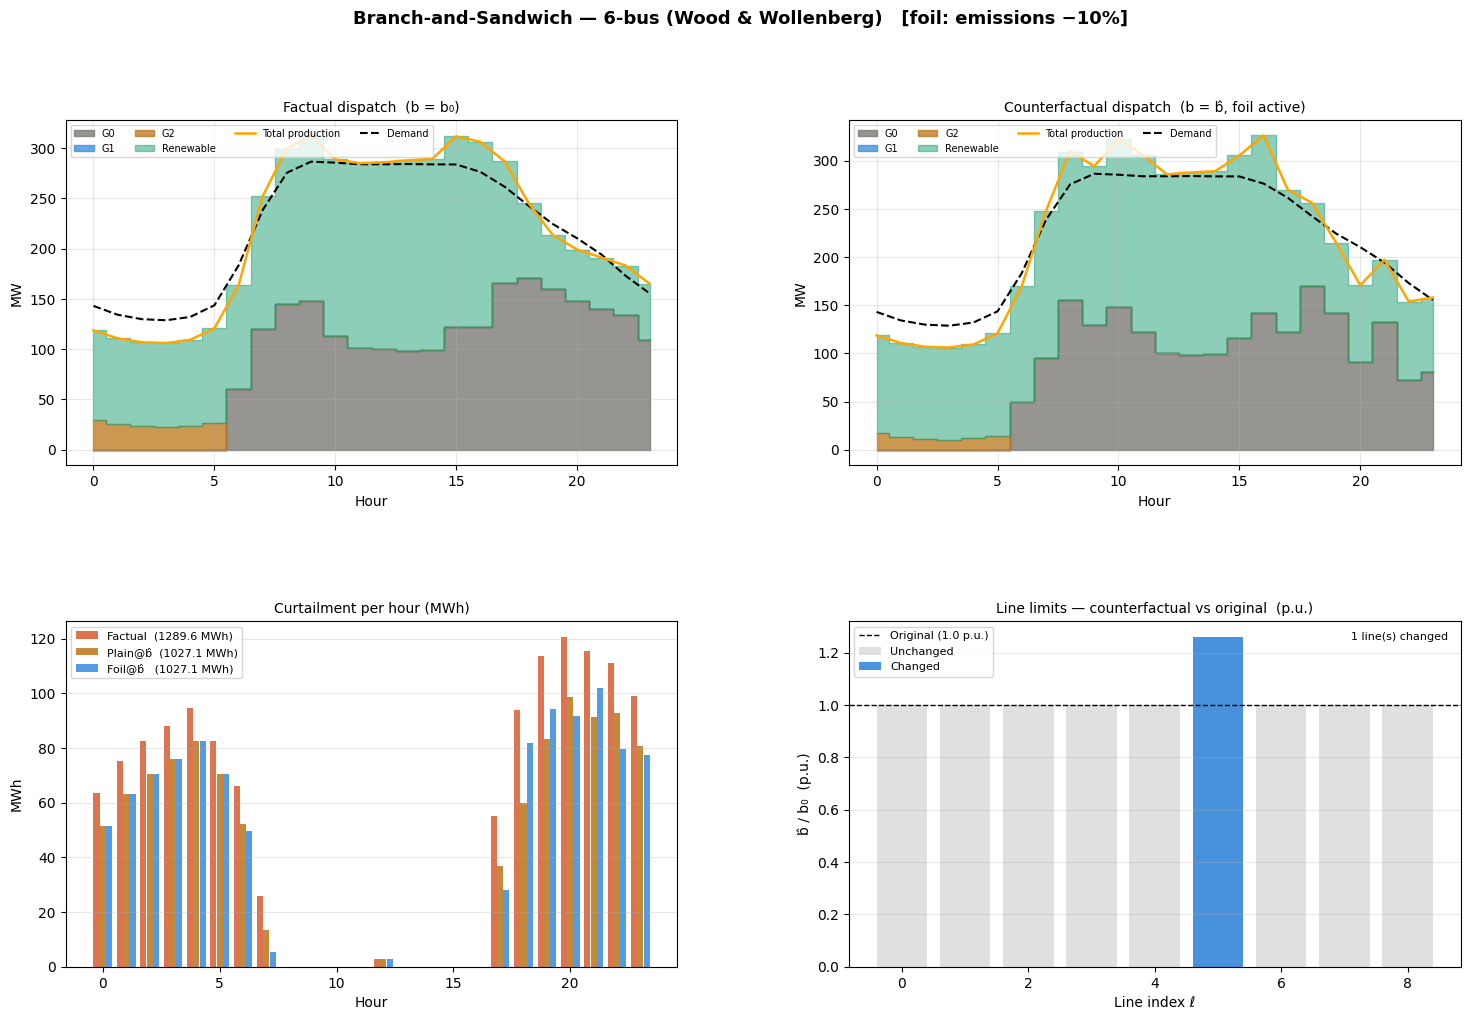


6-bus (Wood & Wollenberg) — B&S summary:
  Nodes processed : 513
  F_opt (incumbent): 1.082812
  Global LB        : 1.082812
  Gap              : 0.000%
  Certified        : True
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
     5   2->4       42.000      52.828    10.828       1.258    +0.258   1.000


In [ ]:
# ── Plot — 6-bus (Wood & Wollenberg) ──────────────────────────────────────────────────────
assert res_bs_6.get("success") and res_bs_6.get("b_hat") is not None, \
    "No incumbent for 6-bus (Wood & Wollenberg)."

b_hat_6 = np.array(res_bs_6["b_hat"], dtype=float)

_,_ , sol_plain_hat_6 = oracle_6.solve_plain(b_hat_6)
_, _,  sol_foil_hat_6 = oracle_6.solve_foil(b_hat_6)

plot_bs_results(
    DATA_6, b0_6, b_hat_6,
    sol0=solF_6,
    sol_plain_hat=sol_plain_hat_6,
    sol_foil_hat=sol_foil_hat_6,
    res_bs=res_bs_6,
    label="6-bus (Wood & Wollenberg)",
    foil_label=f"emissions −{ALPHA:.0%}",
)

### 3.2 · IEEE 14-bus

In [19]:
foil_fn_14_base = make_emissions_foil_4b(DATA_14, alpha=ALPHA, E_factual=E_factual_14)

def foil_fn_14(m, var):
    foil_fn_14_base(m, var)
    m.addConstr(
        gp.quicksum(var["shed"][b, t]
                    for b in range(DATA_14.nB)
                    for t in range(int(DATA_14.T))) == 0,
        name="foil_no_shed"
    )

# Patch the oracle directly
oracle_14.foil_extra_constr_fn = foil_fn_14
oracle_14.cache_foil.clear()

# Verify
vF2, _, solFoil2 = oracle_14.solve_foil(b0_14)
print(f"Foil obj: {vF2}")
print(f"Shed:     {solFoil2['shed'].sum() if solFoil2 else 'N/A'}")

Foil obj: None
Shed:     N/A


In [21]:
# ── Branch-and-Sandwich — IEEE 14-bus ──────────────────────────────────────
assert solFoil_b0_14 is not None, \
    "Foil is infeasible at b0 for IEEE 14-bus — check emissions data."

def _make_emission_viol_fn_14(shed_weight: float = 1.0):
    """
    Returns a violation function for the Branch-and-Sandwich oracle.

    The slack variable s bounds two normalised quantities:
      - emission excess:  (total_emissions - target) / E_factual
      - load shedding:    shed_weight * total_shed / total_demand_MWh

    Both terms are normalised to [0,1] scale so shed_weight=1.0 means
    one MWh of shedding is penalised equally to emitting E_factual tCO2
    above target. Increase shed_weight to make shedding more costly.
    """
    E_f   = E_factual_14
    tgt   = (1 - ALPHA) * E_f
    e_g   = e_14
    nB    = DATA_14.nB
    T     = int(DATA_14.T)

    # Normaliser for shedding: total demand energy over horizon (MWh)
    total_demand_MWh = float(np.sum(DATA_14.demand))

    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")

        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(T)
        )
        total_shed = gp.quicksum(
            var["shed"][b, t]
            for b in range(nB)
            for t in range(T)
        )

        # s >= normalised_emission_excess + normalised_shedding_penalty
        m.addConstr(
            s >= (total_emis - tgt) / max(E_f, 1.0)
               + shed_weight * total_shed / max(total_demand_MWh, 1.0),
            name="emis_viol_constr",
        )
        m.update()
        return s

    return viol_fn

viol_fn_14 = _make_emission_viol_fn_14(shed_weight=1.0)

bs_14 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_14,
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_constr_fn=foil_fn_14,
    b0=b0_14,
    b_bounds=(bL_14, bU_14),
    b_free_idx=b_free_idx_14,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_14,
    foil_violation_expr_fn=viol_fn_14,
    lagrange_penalty=500.0,
    checkpoint_path="bs_14_checkpoint.json",  # <-- add this
)

res_bs_14 = bs_14.run(
    window_size=int(DATA_14.T),
    per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14,
    on_t=on_t_14, off_t=off_t_14,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 14-bus  certified={res_bs_14['certified']}  "
      f"gap={res_bs_14.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_14.get('nodes')}")

[CKPT] Resumed from bs_14_checkpoint.json  bestF=4.1897  nodes_prev=265  gLB=1.9474
[BS] node=0000 olb=1.3377 inner=[19052.18,912361.89] bestF=4.1897 gLB=1.3377 gap=68.1%
  [weak_ok] FAIL: v_D=867113.316236 > v=857101.781891 + eps
  [LAG_OLB] DISCARDED (lag=10.3533 > bestF=4.1897)
  [CKPT] saved → bs_14_checkpoint.json  nodes=1  bestF=4.1897  gLB=1.3377
[BS] node=0001 olb=1.3377 inner=[19052.18,912361.89] bestF=4.1897 gLB=1.3377 gap=68.1%
  [weak_ok] FAIL: v_D=867113.316236 > v=857432.055237 + eps
  [LAG_OLB] DISCARDED (lag=7.8985 > bestF=4.1897)
  [CKPT] saved → bs_14_checkpoint.json  nodes=2  bestF=4.1897  gLB=1.3377
[BS] node=0003 olb=1.3377 inner=[19052.18,912361.89] bestF=4.1897 gLB=1.3377 gap=68.1%
  [weak_ok] FAIL: v_D=867131.218037 > v=857432.055237 + eps
  [LAG_OLB] DISCARDED (lag=5.1767 > bestF=4.1897)
  [CKPT] saved → bs_14_checkpoint.json  nodes=3  bestF=4.1897  gLB=1.3377
[BS] node=0005 olb=1.3377 inner=[19052.18,912361.89] bestF=4.1897 gLB=1.3377 gap=68.1%
  [weak_ok] FAI

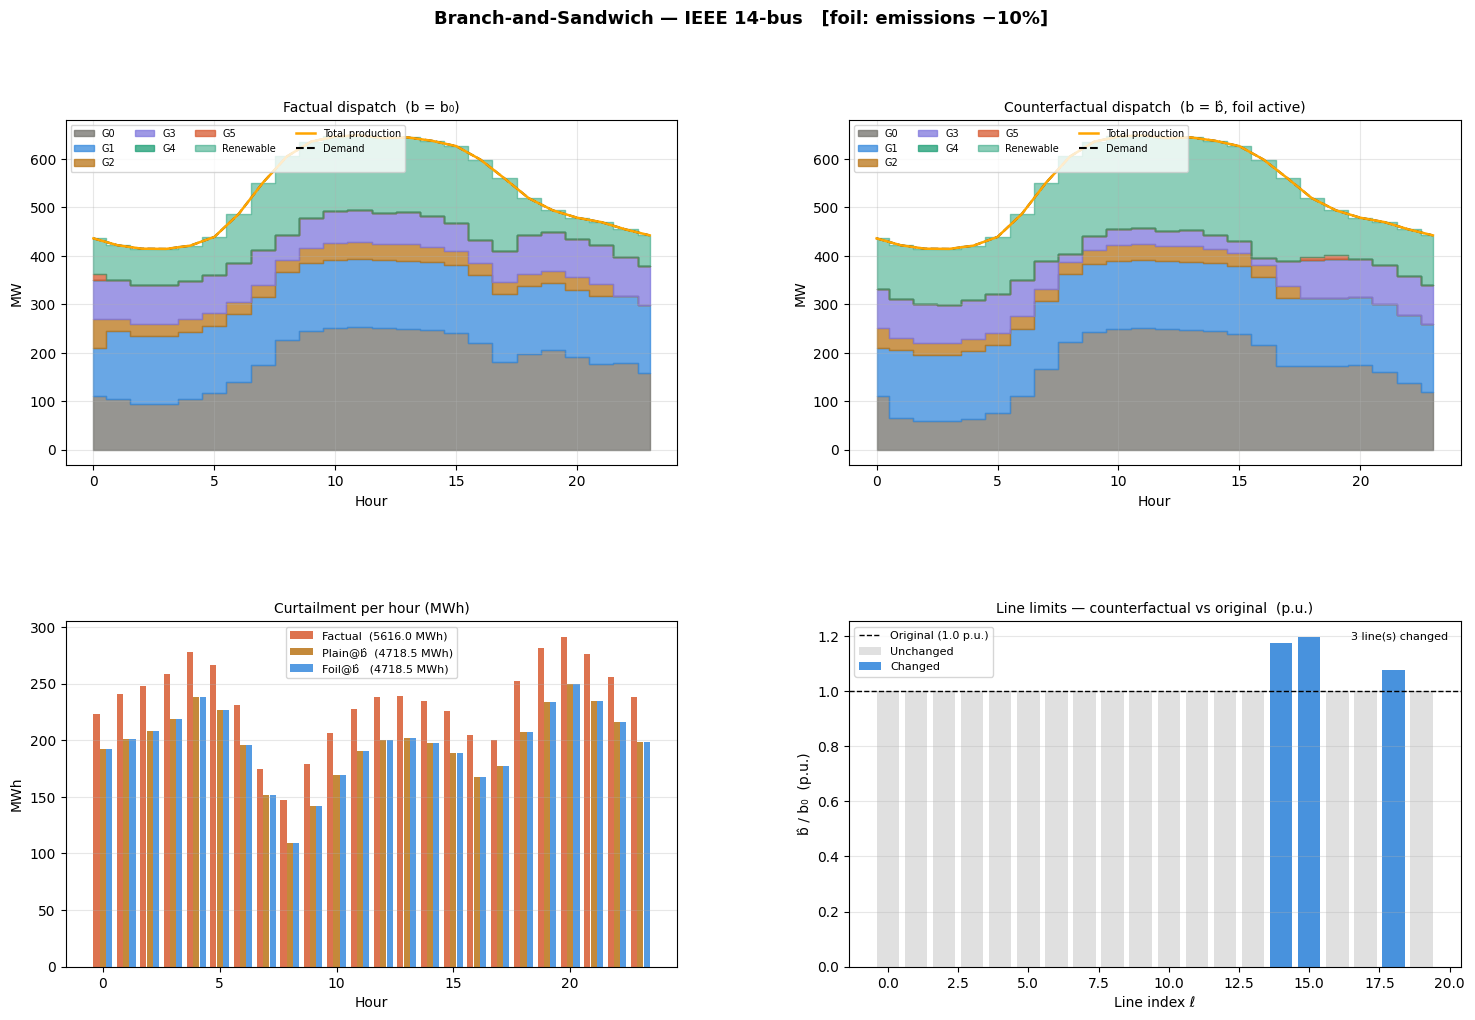


IEEE 14-bus — B&S summary:
  Nodes processed : 1144
  F_opt (incumbent): 2.382312
  Global LB        : 2.382312
  Gap              : 0.000%
  Certified        : True
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    15   8->9       39.000      46.556     7.556       1.194    +0.194   1.000
    14   6->8       39.000      45.825     6.825       1.175    +0.175   1.000
    18  10->11      39.000      41.925     2.925       1.075    +0.075   1.000


In [22]:
# ── Plot — IEEE 14-bus ──────────────────────────────────────────────────────
assert res_bs_14.get("success") and res_bs_14.get("b_hat") is not None, \
    "No incumbent for IEEE 14-bus."

b_hat_14 = np.array(res_bs_14["b_hat"], dtype=float)

_,_ , sol_plain_hat_14 = oracle_14.solve_plain(b_hat_14)
_, _,  sol_foil_hat_14 = oracle_14.solve_foil(b_hat_14)

plot_bs_results(
    DATA_14, b0_14, b_hat_14,
    sol0=solF_14,
    sol_plain_hat=sol_plain_hat_14,
    sol_foil_hat=sol_foil_hat_14,
    res_bs=res_bs_14,
    label="IEEE 14-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

### 3.3 · IEEE 30-bus

In [ ]:
# ── Branch-and-Sandwich — IEEE 30-bus ──────────────────────────────────────
assert solFoil_b0_30 is not None, \
    "Foil is infeasible at b0 for IEEE 30-bus — check emissions data."

def _make_emission_viol_fn_30():
    E_f  = E_factual_30
    tgt  = (1 - ALPHA) * E_f
    e_g  = e_30
    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")
        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(int(DATA_30.T))
        )
        m.addConstr(s >= (total_emis - tgt) / max(E_f, 1.0), name="emis_viol_constr")
        m.update()
        return s
    return viol_fn

viol_fn_30 = _make_emission_viol_fn_30()

bs_30 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_30,
    data=DATA_30, idx=idx_30, cvec=cvec_30,
    foil_extra_constr_fn=foil_fn_30,
    b0=b0_30,
    b_bounds=(bL_30, bU_30),
    b_free_idx=b_free_idx_30,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_30,
    foil_violation_expr_fn=viol_fn_30,
    lagrange_penalty=200.0,
)

res_bs_30 = bs_30.run(
    window_size=int(DATA_30.T),
    per_bus_neutrality=True,
    u_init=u_init_30, p_init=p_init_30,
    on_t=on_t_30, off_t=off_t_30,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 30-bus  certified={res_bs_30['certified']}  "
      f"gap={res_bs_30.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_30.get('nodes')}")

  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2459459.328477 > v=361513.915160 + eps
  [INNER_UB] best_inner_ub=363356.1091
[BS] node=0000 olb=0.0000 inner=[8.00,363356.11] bestF=inf gLB=0.0000 gap=nan%
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2608167.713477 > v=362319.424460 + eps
  [weak_ok] FAIL: v_D=2459459.328477 > v=361513.915160 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2800025.681477 > v=363356.109080 + eps
  [weak_ok] FAIL: v_D=2704095.713477 > v=362852.224460 + eps
  [weak_ok] FAIL: v_D=260816

In [ ]:
# ── Plot — IEEE 30-bus ──────────────────────────────────────────────────────
assert res_bs_30.get("success") and res_bs_30.get("b_hat") is not None, \
    "No incumbent for IEEE 30-bus."

b_hat_30 = np.array(res_bs_30["b_hat"], dtype=float)

_,_ , sol_plain_hat_30 = oracle_30.solve_plain(b_hat_30)
_, _,  sol_foil_hat_30 = oracle_30.solve_foil(b_hat_30)

plot_bs_results(
    DATA_30, b0_30, b_hat_30,
    sol0=solF_30,
    sol_plain_hat=sol_plain_hat_30,
    sol_foil_hat=sol_foil_hat_30,
    res_bs=res_bs_30,
    label="IEEE 30-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

AssertionError: No incumbent for IEEE 30-bus.

### 3.4 · IEEE 39-bus

In [7]:
# ── Branch-and-Sandwich — IEEE 39-bus ──────────────────────────────────────
def _make_emission_viol_fn_39(shed_weight: float = 1.0):
    """
    Returns a violation function for the Branch-and-Sandwich oracle.

    The slack variable s bounds two normalised quantities:
      - emission excess:  (total_emissions - target) / E_factual
      - load shedding:    shed_weight * total_shed / total_demand_MWh

    Both terms are normalised to [0,1] scale so shed_weight=1.0 means
    one MWh of shedding is penalised equally to emitting E_factual tCO2
    above target. Increase shed_weight to make shedding more costly.
    """
    E_f   = E_factual_39
    tgt   = (1 - ALPHA) * E_f
    e_g   = e_39
    nB    = DATA_39.nB
    T     = int(DATA_39.T)

    # Normaliser for shedding: total demand energy over horizon (MWh)
    total_demand_MWh = float(np.sum(DATA_39.demand))

    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")

        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(T)
        )
        total_shed = gp.quicksum(
            var["shed"][b, t]
            for b in range(nB)
            for t in range(T)
        )

        # s >= normalised_emission_excess + normalised_shedding_penalty
        m.addConstr(
            s >= (total_emis - tgt) / max(E_f, 1.0)
               + shed_weight * total_shed / max(total_demand_MWh, 1.0),
            name="emis_viol_constr",
        )
        m.update()
        return s

    return viol_fn


viol_fn_39 = _make_emission_viol_fn_39(shed_weight=1.0)


bs_39 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_39,
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    foil_extra_constr_fn=foil_fn_39,
    b0=b0_39,
    b_bounds=(bL_39, bU_39),
    b_free_idx=b_free_idx_39,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_39,
    foil_violation_expr_fn=viol_fn_39,
    lagrange_penalty=1000.0,
    checkpoint_path="bs_39_checkpoint_test.json",  # <-- add this
    node_selection="fifo",
)

res_bs_39 = bs_39.run(
    window_size=int(DATA_39.T),
    per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39,
    on_t=on_t_39, off_t=off_t_39,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 39-bus  certified={res_bs_39['certified']}  "
      f"gap={res_bs_39.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_39.get('nodes')}")

[CKPT] Resumed from bs_39_checkpoint_test.json  bestF=0.9016  nodes_prev=144  gLB=0.0000
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=188633.142928 > v=188633.141907 + eps
[BS] node=0000 olb=0.0000 inner=[2485.99,461623.68] bestF=0.9016 gLB=0.0000 gap=100.0%
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=188633.142928 > v=188633.141907 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680791 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1227625.970700 > v=461623.680934 + eps
  [weak_ok] FAIL: v_D=1057742.617077 > v=456554.392919 + eps
  [weak_ok] FAIL: v_D=614612.8094

KeyboardInterrupt: 


IEEE 39-bus — B&S summary:
  Nodes processed : 1628
  F_opt (incumbent): 0.901609
  Global LB        : 0.520985
  Gap              : 42.216%
  Certified        : False
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    13   7->8      192.000     195.600     3.600       1.019    +0.019   1.000


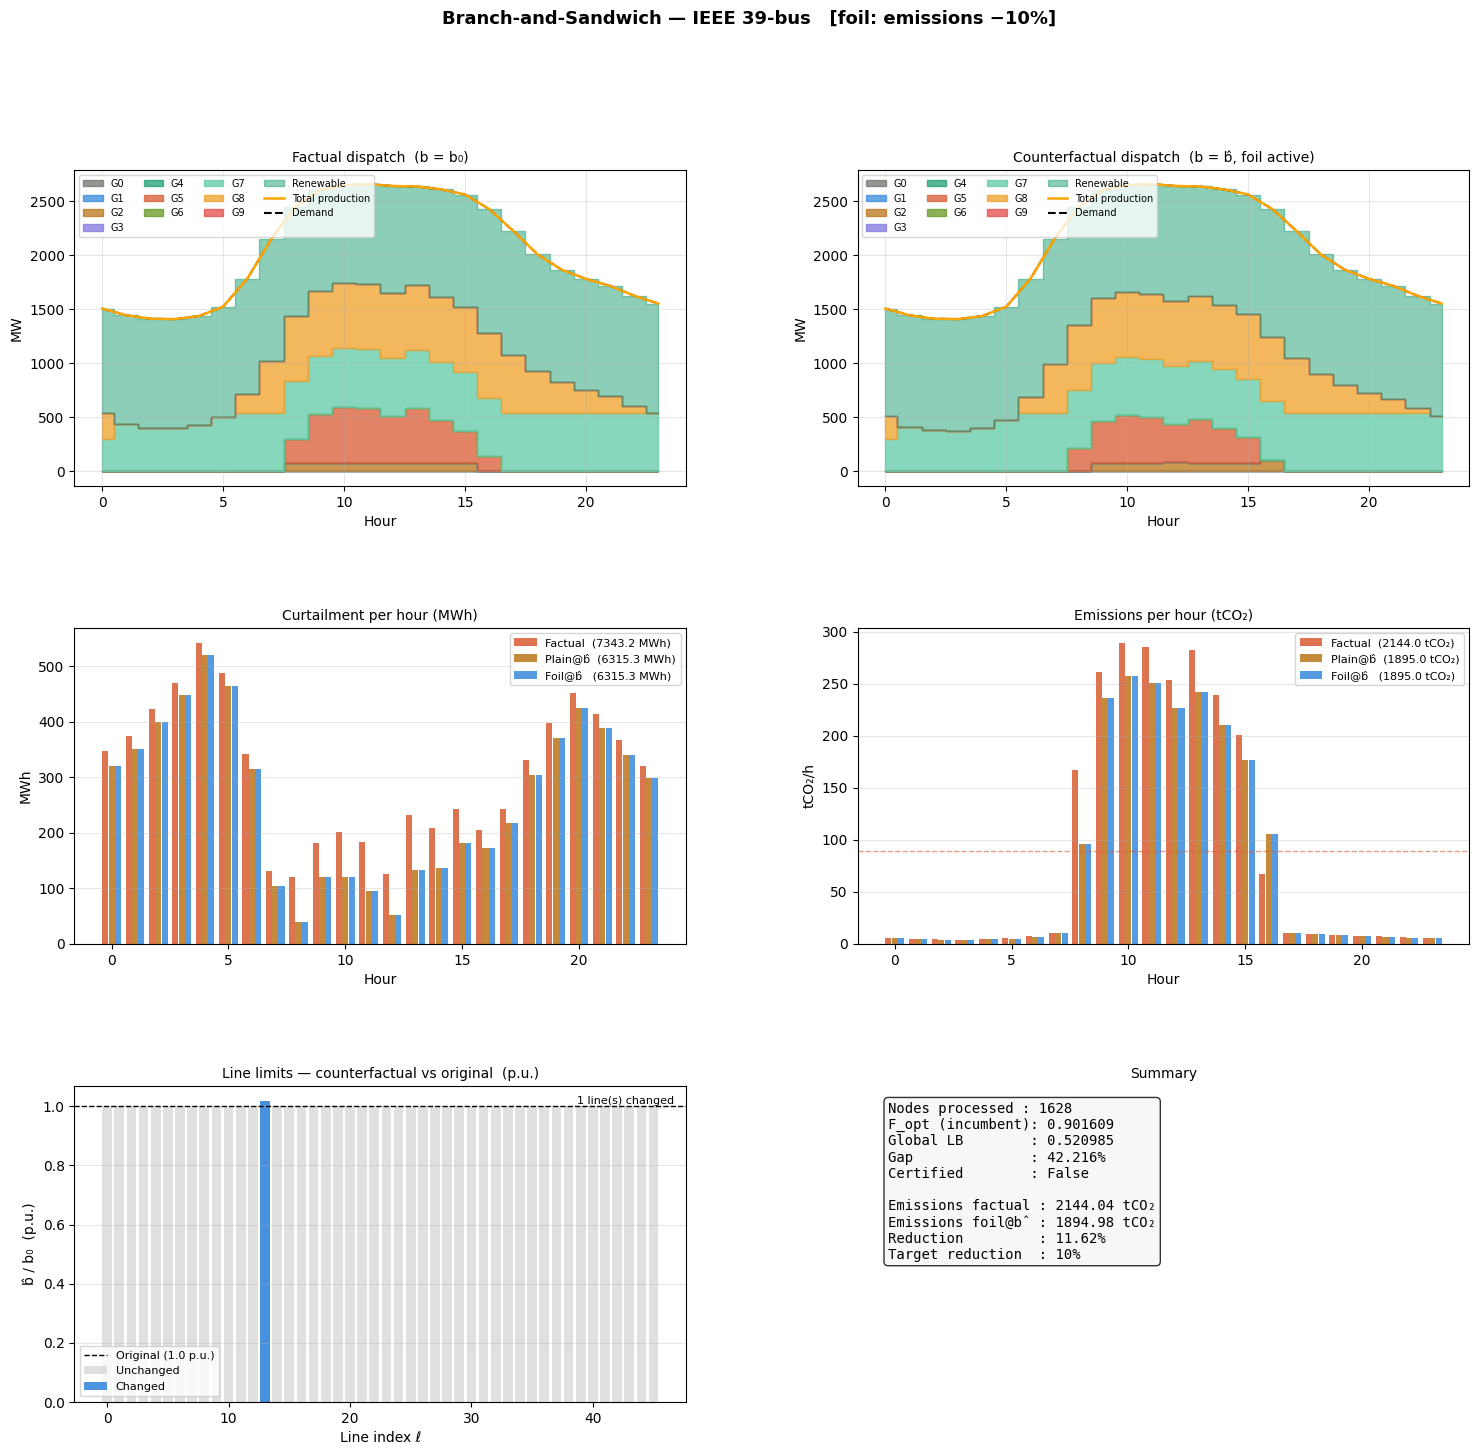

In [12]:
# ── Plot — IEEE 39-bus ──────────────────────────────────────────────────────
b_hat_39 = np.array( [
    600.0,
    1000.0,
    600.0,
    500.0,
    192.0,
    600.0,
    192.0,
    192.0,
    1200.0,
    192.0,
    600.0,
    600.0,
    192.0,
    195.60000000000002,
    1000.0,
    600.0,
    600.0,
    600.0,
    192.0,
    192.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    1200.0,
    600.0,
    600.0,
    192.0,
    600.0,
    600.0,
    600.0,
    600.0,
    600.0,
    192.0
  ], dtype=float)

res_bs_39 = {
    "success":       True,
    "b_hat":         b_hat_39,
    "F_opt":         0.9016088736790557,
    "nodes":         1628,
    "v_plain":       411606.1944239526,
    "v_D":           411606.1944239526,
    "global_LB":     0.5209845150087588,
    "gap":           0.9016088736790557 - 0.5209845150087588,
    "best_inner_ub": 216736.33669083554,
    "certified":     False,
    "mip_lb_used":   False,
}




_,_ , sol_plain_hat_39 = oracle_39.solve_plain(b_hat_39)
_, _,  sol_foil_hat_39  = oracle_39.solve_foil(b_hat_39)

plot_bs_results(
    DATA_39, b0_39, b_hat_39,
    sol0=solF_39,
    sol_plain_hat=sol_plain_hat_39,
    sol_foil_hat=sol_foil_hat_39,
    res_bs=res_bs_39,
    label="IEEE 39-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

### 3.5 · IEEE 57-bus

In [6]:
import os
if os.path.exists("bs_57_checkpoint_test.json"):
    os.remove("bs_57_checkpoint_test.json")

assert solFoil_b0_57 is None, "Foil feasible at b0 — CE trivially exists, no B&S needed"

def _make_viol_fn_57(shed_weight: float = 1.0):
    E_f              = E_factual_57
    tgt              = (1 - ALPHA) * E_f
    e_g              = e_57
    nB               = DATA_57.nB
    T                = int(DATA_57.T)
    total_demand_MWh = float(np.sum(DATA_57.demand))

    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")
        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g)) for t in range(T)
        )
        total_shed = gp.quicksum(
            var["shed"][b, t]
            for b in range(nB) for t in range(T)
        )
        m.addConstr(
            s >= (total_emis - tgt) / max(E_f, 1.0)
               + shed_weight * total_shed / max(total_demand_MWh, 1.0),
            name="emis_viol_constr",
        )
        m.update()
        return s

    return viol_fn

viol_fn_57 = _make_viol_fn_57(shed_weight=1.0)

bs_57 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_57,
    data=DATA_57, idx=idx_57, cvec=cvec_57,
    foil_extra_constr_fn=foil_fn_57,
    b0=b0_57,
    b_bounds=(bL_57, bU_57),
    b_free_idx=b_free_idx_57,
    eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None, master_time_limit=None,
    output_flag=0, verbose=True,
    w=w_57,
    foil_violation_expr_fn=viol_fn_57,
    lagrange_penalty=200.0,
    checkpoint_path="bs_57_checkpoint_test.json",
    checkpoint_interval=1,
)

res_bs_57 = bs_57.run(
    window_size=int(DATA_57.T),
    per_bus_neutrality=True,
    u_init=u_init_57, p_init=p_init_57,
    on_t=on_t_57, off_t=off_t_57,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 57-bus  certified={res_bs_57['certified']}  "
      f"gap={res_bs_57.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_57.get('nodes')}")

  [INC] b_max: F=44.3524 v=974915.459 v_D=974915.459
  [INNER_UB] tightened by incumbent: 974915.4589
[BS] node=0000 olb=11.6796 inner=[94982.50,1087876.06] bestF=44.3524 gLB=11.6796 gap=73.7%
  [INC] node=0000: F=11.6796 v=1001408.253 v_D=1001408.253
  [CKPT] saved → bs_57_checkpoint_test.json  nodes=1  bestF=11.6796  gLB=0.0000
  [LP_OLB] Infeasible node=1
  [CKPT] saved → bs_57_checkpoint_test.json  nodes=3  bestF=11.6796  gLB=11.6796

IEEE 57-bus  certified=False  gap=0.0000  nodes=3


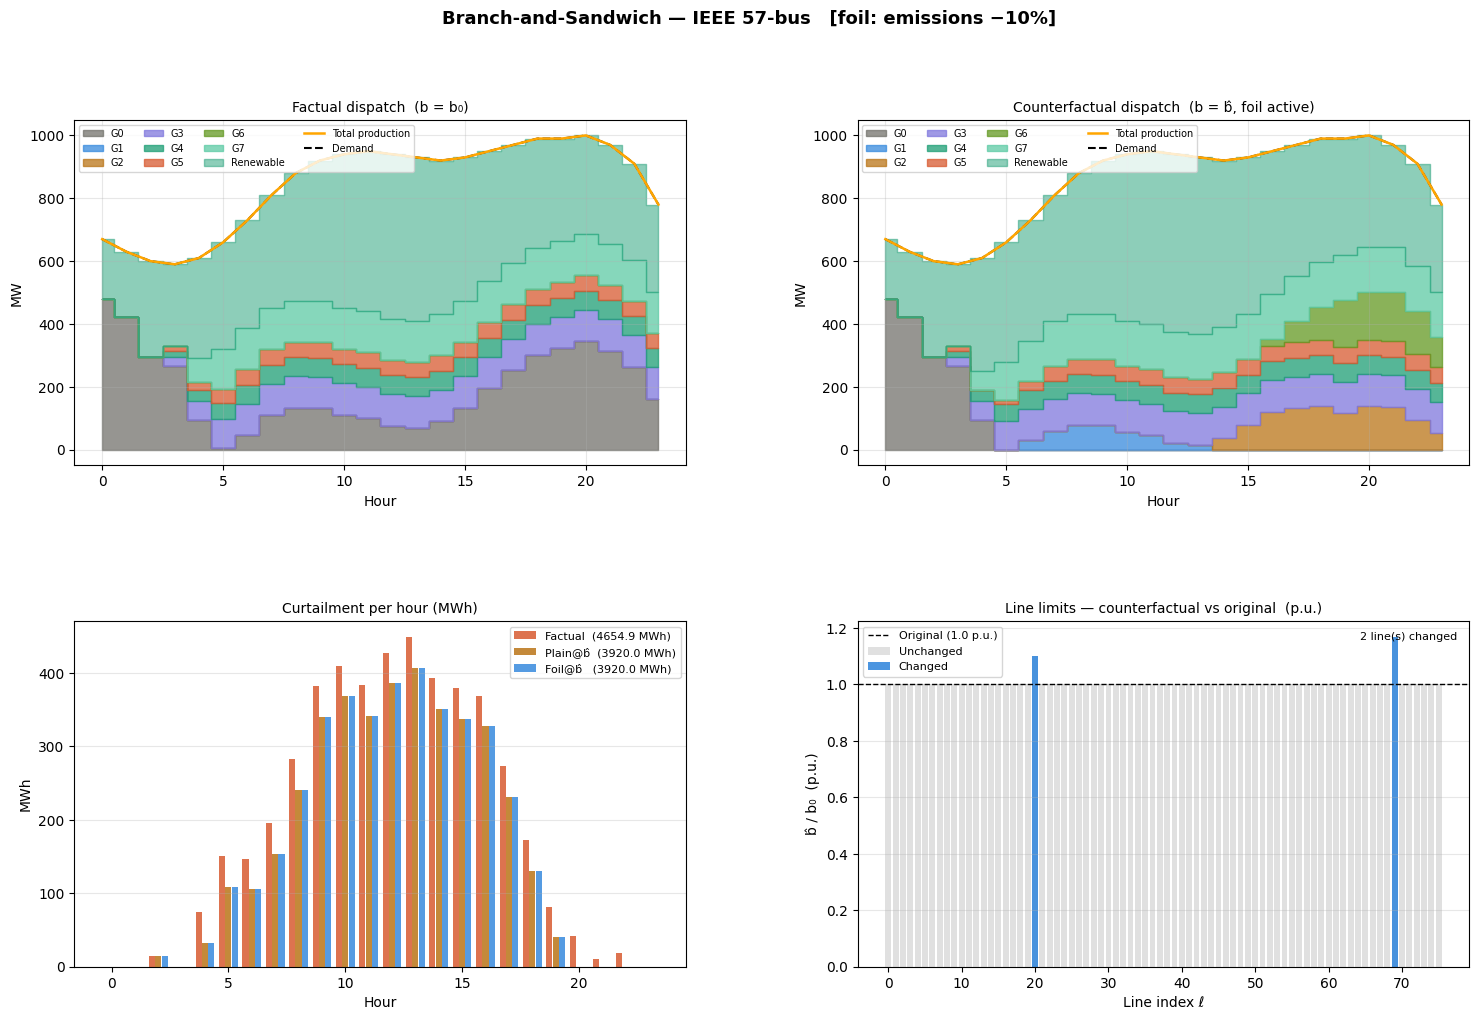


IEEE 57-bus — B&S summary:
  Nodes processed : 3
  F_opt (incumbent): 11.679577
  Global LB        : 11.679577
  Gap              : 0.000%
  Certified        : False
   ell  fr->to     b0(MW)   b_hat(MW)     Δ(MW)   b_hat(pu)     Δ(pu)    util
    69  55->56     250.000     291.538    41.538       1.166    +0.166   1.000
    20  10->41     130.000     143.133    13.133       1.101    +0.101   1.000


In [7]:
# ── Plot — IEEE 57-bus ──────────────────────────────────────────────────────
assert res_bs_57.get("success") and res_bs_57.get("b_hat") is not None, \
    "No incumbent for IEEE 57-bus."

b_hat_57 = np.array(res_bs_57["b_hat"], dtype=float)


_,_ , sol_plain_hat_57 = oracle_57.solve_plain(b_hat_57)
_, _,  sol_foil_hat_57  = oracle_57.solve_foil(b_hat_57)

plot_bs_results(
    DATA_57, b0_57, b_hat_57,
    sol0=solF_57,
    sol_plain_hat=sol_plain_hat_57,
    sol_foil_hat=sol_foil_hat_57,
    res_bs=res_bs_57,
    label="IEEE 57-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

In [ ]:
obj_hat,_ , sol_plain_hat_57 = oracle_57.solve_plain(b_hat_57)
obj_factual,_ , sol_plain_factual_57 = oracle_57.solve_plain(b0_57)

In [ ]:
print(f"\nIEEE 57-bus  |  Factual vs Plain@b̂ comparison:")
print(f"  Factual obj        : {obj_factual:.0f}")
print(f"  Plain@b̂ obj       : {obj_hat:.0f}")
print(f"  Factual emissions  : {E_factual_57:.2f} tCO2")
print(f"  Plain@b̂ emissions : {float(np.sum(e_57[:, None   ] * sol_plain_hat_57['p'])):.2f} tCO2")
print(f"  Factual shed       : {solF_57['shed'].sum():.1f} MWh")
print(f"  Plain@b̂ shed      : {sol_plain_hat_57['shed'].sum():.1f} MWh")
print(f"reduction in obj:     {(obj_factual - obj_hat):.0f}  ({100.0 * (obj_factual - obj_hat) / abs(obj_factual):.2f}%)")
print(f"reduction in emissions: {(E_factual_57 - float(np.sum(e_57[:, None] * sol_plain_hat_57['p']))):.2f} tCO2  "
      f"({100.0 * (E_factual_57 - float(np.sum(e_57[:, None] * sol_plain_hat_57['p']))) / E_factual_57:.2f}%)")



IEEE 57-bus  |  Factual vs Plain@b̂ comparison:
  Factual obj        : 1087459
  Plain@b̂ obj       : 993956
  Factual emissions  : 7188.63 tCO2
  Plain@b̂ emissions : 6324.33 tCO2
  Factual shed       : 0.0 MWh
  Plain@b̂ shed      : 0.0 MWh
reduction in obj:     93503  (8.60%)
reduction in emissions: 864.29 tCO2  (12.02%)


### 3.6 · IEEE 118-bus

In [ ]:
# ── Branch-and-Sandwich — IEEE 118-bus ──────────────────────────────────────
assert solFoil_b0_118 is not None, \
    "Foil is infeasible at b0 for IEEE 118-bus — check emissions data."

def _make_emission_viol_fn_118():
    E_f  = E_factual_118
    tgt  = (1 - ALPHA) * E_f
    e_g  = e_118
    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")
        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(int(DATA_118.T))
        )
        m.addConstr(s >= (total_emis - tgt) / max(E_f, 1.0), name="emis_viol_constr")
        m.update()
        return s
    return viol_fn

viol_fn_118 = _make_emission_viol_fn_118()

bs_118 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_118,
    data=DATA_118, idx=idx_118, cvec=cvec_118,
    foil_extra_constr_fn=foil_fn_118,
    b0=b0_118,
    b_bounds=(bL_118, bU_118),
    b_free_idx=b_free_idx_118,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_118,
    foil_violation_expr_fn=viol_fn_118,
    lagrange_penalty=200.0,
)

res_bs_118 = bs_118.run(
    window_size=int(DATA_118.T),
    per_bus_neutrality=True,
    u_init=u_init_118, p_init=p_init_118,
    on_t=on_t_118, off_t=off_t_118,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 118-bus  certified={res_bs_118['certified']}  "
      f"gap={res_bs_118.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_118.get('nodes')}")

In [ ]:
# ── Plot — IEEE 118-bus ──────────────────────────────────────────────────────
assert res_bs_118.get("success") and res_bs_118.get("b_hat") is not None, \
    "No incumbent for IEEE 118-bus."

b_hat_118 = np.array(res_bs_118["b_hat"], dtype=float)

_,_ ,sol_plain_hat_118, _ = oracle_118.solve_plain(b_hat_118)
_, _,  sol_foil_hat_118  = oracle_118.solve_foil(b_hat_118)

plot_bs_results(
    DATA_118, b0_118, b_hat_118,
    sol0=solF_118,
    sol_plain_hat=sol_plain_hat_118,
    sol_foil_hat=sol_foil_hat_118,
    res_bs=res_bs_118,
    label="IEEE 118-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

### 3.7 · IEEE 300-bus

In [ ]:
# ── Branch-and-Sandwich — IEEE 300-bus ──────────────────────────────────────
assert solFoil_b0_300 is not None, \
    "Foil is infeasible at b0 for IEEE 300-bus — check emissions data."

def _make_emission_viol_fn_300():
    E_f  = E_factual_300
    tgt  = (1 - ALPHA) * E_f
    e_g  = e_300
    def viol_fn(m, var, idx):
        s = m.addVar(lb=0.0, name="emis_viol")
        total_emis = gp.quicksum(
            e_g[g] * var["p"][g, t]
            for g in range(len(e_g))
            for t in range(int(DATA_300.T))
        )
        m.addConstr(s >= (total_emis - tgt) / max(E_f, 1.0), name="emis_viol_constr")
        m.update()
        return s
    return viol_fn

viol_fn_300 = _make_emission_viol_fn_300()

bs_300 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_300,
    data=DATA_300, idx=idx_300, cvec=cvec_300,
    foil_extra_constr_fn=foil_fn_300,
    b0=b0_300,
    b_bounds=(bL_300, bU_300),
    b_free_idx=b_free_idx_300,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_300,
    foil_violation_expr_fn=viol_fn_300,
    lagrange_penalty=200.0,
)

res_bs_300 = bs_300.run(
    window_size=int(DATA_300.T),
    per_bus_neutrality=True,
    u_init=u_init_300, p_init=p_init_300,
    on_t=on_t_300, off_t=off_t_300,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\nIEEE 300-bus  certified={res_bs_300['certified']}  "
      f"gap={res_bs_300.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_300.get('nodes')}")

In [ ]:
# ── Plot — IEEE 300-bus ──────────────────────────────────────────────────────
assert res_bs_300.get("success") and res_bs_300.get("b_hat") is not None, \
    "No incumbent for IEEE 300-bus."

b_hat_300 = np.array(res_bs_300["b_hat"], dtype=float)

_,_, sol_plain_hat_300, _ = oracle_300.solve_plain(b_hat_300)
_, _,  sol_foil_hat_300  = oracle_300.solve_foil(b_hat_300)

plot_bs_results(
    DATA_300, b0_300, b_hat_300,
    sol0=solF_300,
    sol_plain_hat=sol_plain_hat_300,
    sol_foil_hat=sol_foil_hat_300,
    res_bs=res_bs_300,
    label="IEEE 300-bus",
    foil_label=f"emissions −{ALPHA:.0%}",
)

### Bonus · 6-bus — commitment-flip foil

Run B&S on the 6-bus grid a second time using the best **commitment-flip foil**
(force generator ON/OFF) found by `scan_foil_candidates`.
This allows direct comparison with the emissions foil above.

In [ ]:
# ── Scan commitment-flip foil candidates — 6-bus ─────────────────────────
candidates_6_flip = scan_foil_candidates(
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    solF=solF_6, zF=zF_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_t=on_t_6, off_t=off_t_6,
    min_gap=100, max_gap=1e7, block_len_range=(2, 4),
)

if candidates_6_flip:
    best_gap_6f, best_g_6f, best_times_6f, best_type_6f = candidates_6_flip[0]
    foil_fn_6_flip = (foil_force_on(g=best_g_6f, times=best_times_6f)
                      if best_type_6f == "ON"
                      else foil_force_off(g=best_g_6f, times=best_times_6f))
    print(f"Selected commitment-flip foil: G{best_g_6f} {best_type_6f} "
          f"at t={best_times_6f}  gap={best_gap_6f:.0f}")
else:
    print("No commitment-flip foil found for 6-bus — adjust min_gap/max_gap.")
    foil_fn_6_flip = None

In [ ]:
# ── B&S with commitment-flip foil — 6-bus ────────────────────────────────
assert foil_fn_6_flip is not None, "No commitment-flip foil available — run cell above."

oracle_6_flip = UCWeakWCEOracle(
    data=DATA_6, cvec=cvec_6, idx=idx_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6, on_t=on_t_6, off_t=off_t_6,
    foil_extra_constr_fn=foil_fn_6_flip,
    output_flag=0, time_limit=None, cache_decimals=3,
)

# Verify foil feasibility at b0
vF_6f, _, solFoil_6f_b0 = oracle_6_flip.solve_foil(b0_6)
assert solFoil_6f_b0 is not None, "Commitment-flip foil is infeasible at b0 for 6-bus."

# Violation function for commitment-flip foil (objective distance proxy)
def viol_fn_6_flip(m, var, idx):
    """No soft-violation structure needed — commitment flip is already binary.
    Use a constant-zero slack (B&S will rely purely on feasibility checks)."""
    s = m.addVar(lb=0.0, ub=0.0, name="flip_viol_zero")
    m.update()
    return s

bs_6_flip = UCBranchAndSandwichWCE_4b(
    oracle=oracle_6_flip,
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    foil_extra_constr_fn=foil_fn_6_flip,
    b0=b0_6,
    b_bounds=(bL_6, bU_6),
    b_free_idx=b_free_idx_6,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=maxnodes,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w_6,
    foil_violation_expr_fn=viol_fn_6_flip,
    lagrange_penalty=200.0,
)

res_bs_6_flip = bs_6_flip.run(
    window_size=int(DATA_6.T),
    per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6,
    on_t=on_t_6, off_t=off_t_6,
    compute_final_mip_lb=True,
    mip_lb_time_limit=3600.0,
)

print(f"\n6-bus (commitment flip)  certified={res_bs_6_flip['certified']}  "
      f"gap={res_bs_6_flip.get('gap', float('nan')):.4f}  "
      f"nodes={res_bs_6_flip.get('nodes')}")

In [ ]:
# ── Plot — 6-bus commitment-flip foil ────────────────────────────────────
assert res_bs_6_flip.get("success") and res_bs_6_flip.get("b_hat") is not None, \
    "No incumbent for 6-bus commitment-flip experiment."

b_hat_6_flip = np.array(res_bs_6_flip["b_hat"], dtype=float)

_, sol_plain_hat_6_flip, _ = oracle_6_flip.solve_plain(b_hat_6_flip)
_, sol_foil_hat_6_flip,  _ = oracle_6_flip.solve_foil(b_hat_6_flip)

flip_desc = f"G{best_g_6f} {best_type_6f} at t={best_times_6f}"
plot_bs_results(
    DATA_6, b0_6, b_hat_6_flip,
    sol0=solF_6,
    sol_plain_hat=sol_plain_hat_6_flip,
    sol_foil_hat=sol_foil_hat_6_flip,
    res_bs=res_bs_6_flip,
    label="6-bus (commitment flip)",
    foil_label=flip_desc,
)

---
## Section 4 · Cross-grid comparison

Summary table across all seven grids (emissions foil, α = 20 %).

In [ ]:
print(f"{'Grid':<18} {'Free lines':>12} {'F_opt':>12} {'Gap %':>8} {'Nodes':>8} {'Certified':>10}")
print("\u2500" * 74)

grid_specs = [
    ("6-bus (WW)",   "6"),
    ("IEEE 14-bus",  "14"),
    ("IEEE 30-bus",  "30"),
    ("IEEE 39-bus",  "39"),
    ("IEEE 57-bus",  "57"),
    ("IEEE 118-bus", "118"),
    ("IEEE 300-bus", "300"),
]

for lbl, key in grid_specs:
    res   = eval(f"res_bs_{key}")
    b_fi  = eval(f"b_free_idx_{key}")
    F_opt = float(res.get("F_opt", float("nan")))
    LB    = res.get("global_LB", res.get("LB", float("nan")))
    LB    = float(LB) if LB is not None else float("nan")
    gap_pct = (100.0 * max(0.0, F_opt - LB) / abs(F_opt)
               if (np.isfinite(F_opt) and np.isfinite(LB) and abs(F_opt) > 1e-12)
               else float("nan"))
    nodes = res.get("nodes", "—")
    cert  = str(res.get("certified", "—"))
    print(f"{lbl:<18} {str(b_fi):>12} {F_opt:>12.4f} {gap_pct:>7.2f}% {str(nodes):>8} {cert:>10}")

print()
print("─── 6-bus commitment-flip comparison ───────────────────────────────")
res_f  = res_bs_6_flip
F_f    = float(res_f.get("F_opt", float("nan")))
LB_f   = float(res_f.get("global_LB", res_f.get("LB", float("nan"))) or float("nan"))
gap_f  = (100.0 * max(0.0, F_f - LB_f) / abs(F_f)
          if np.isfinite(F_f) and np.isfinite(LB_f) and abs(F_f) > 1e-12 else float("nan"))
F_e    = float(res_bs_6.get("F_opt", float("nan")))
print(f"  Emissions foil  F_opt = {F_e:.4f}")
print(f"  Commit-flip foil F_opt = {F_f:.4f}  gap={gap_f:.2f}%  "
      f"certified={res_f.get('certified')}")